Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
CC3084 - Data Science - sección 40

Cristian Túnchez (231359)  
Nadissa Vela (23764)

# Laboratorio 6: Análisis de Redes Sociales en YouTube

## Notebook 1 - Carga, comprensión, integración y limpieza

Este notebook resuelve los **Ejercicios 1 y 2** del laboratorio.

En este notebook se cargan los dos conjuntos de datos recolectados de YouTube, se identifica cómo se relacionan entre sí, se diagnostica su calidad y se produce una versión limpia de ambos que servirá de insumo para el análisis exploratorio y para la construcción de las redes.

**Preparación del entorno**

Se importan las librerías necesarias y se fija un estilo común para todos los gráficos. El módulo `src/utils.py` aporta únicamente las rutas del proyecto y ayudas de guardado.

In [1]:
import re
import sys
import ast
import unicodedata
from urllib.parse import unquote
from pathlib import Path

import emoji
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy

sys.path.insert(0, str(Path.cwd().parent))
from src.utils import DATA_RAW, set_estilo, guardar

set_estilo()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("pandas:", pd.__version__, "| spaCy:", spacy.__version__)
print("Datos crudos en:", DATA_RAW)

pandas: 2.3.3 | spaCy: 3.8.16
Datos crudos en: /home/sebas/github/Data-Science/CC3084-Laboratorio-6/data/raw


## Ejercicio 1. Carga, comprensión e integración de los datos

### 1.1 Carga de los archivos

In [2]:
videos = pd.read_csv(DATA_RAW / "youtube_videos.csv")
comentarios = pd.read_csv(DATA_RAW / "youtube_comments.csv")

print(f"youtube_videos.csv   -> {videos.shape[0]} filas x {videos.shape[1]} columnas")
print(f"youtube_comments.csv -> {comentarios.shape[0]} filas x {comentarios.shape[1]} columnas")

youtube_videos.csv   -> 293 filas x 20 columnas
youtube_comments.csv -> 406 filas x 17 columnas


In [3]:
# Primeras filas de cada archivo, transpuestas para poder leer todas las columnas
videos.head(2).T

,0,1
video_id,-5puKGEqcUc,-E7OPOLjMug
title,INSIVUMEH pronostica incremento de lluvias par...,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO...
channel_name,T13 Noticias Guatemala,IDocumenta
channel_id,UCq0Cm-3SKthEySQc2JZBi1A,UCgItjn_ZWFWcv1MlpKIkqgQ
source_query,guatemala lluvias,@GobiernodelaRepublicadeGuatema
source_group,topic,topic
dataset_sources,youtube_guatemala.csv | youtube_guatemala_lab....,youtube_target_channels.csv
channel_handle,/@T13NoticiasGuatemala,/@iDocumenta
published_time,hace 2 días,hace 3 meses
view_count_text,"2,390 vistas",4 vistas


In [4]:
comentarios.head(2).T

,0,1
video_id,j43HgwYFKfk,06mFNPU0aB8
comment_id,Ugw-J65a1iYL9hqhELh4AaABAg,Ugw-ZT9t9wU2V-tCaUZ4AaABAg
video_title,La cooptación de Walter Mazariegos en la USAC,Capturan a presuntos delincuentes disfrazados ...
channel_name,Quorum,Noti7
channel_id,UCE4rsXcgDb6e1-a9iTbWzfg,UCVpSRoZgngfSL03Nlbjtq9A
author_name,@MarcosCarillo-b1r,@RaulPerez-cw2vi
author_channel_id,UCdFlugHJJa4l3YqWuNRmvXw,UCvl1tzQeBeGy6efPTRJXSCw
text,Ese corrupto amigo de la vieja fiscal los teng...,"Están jóvenes porque no buscan un trabajo, tu..."
source_query,@quorumgt,guatemala noticias
source_group,topic,topic


### 1.2 Unidad de observación, llave primaria y variables relevantes

Se comprueba con los datos que las llaves primarias son efectivamente únicas y no tienen valores faltantes.

In [5]:
def revisar_llave(df, columna, nombre):
    return {
        "conjunto": nombre,
        "llave": columna,
        "filas": len(df),
        "valores_unicos": df[columna].nunique(),
        "es_unica": bool(df[columna].is_unique),
        "faltantes": int(df[columna].isna().sum()),
    }

pd.DataFrame([
    revisar_llave(videos, "video_id", "youtube_videos"),
    revisar_llave(comentarios, "comment_id", "youtube_comments"),
])

,conjunto,llave,filas,valores_unicos,es_unica,faltantes
0,youtube_videos,video_id,293,293,True,0
1,youtube_comments,comment_id,406,406,True,0


In [6]:
# Clasificación de las variables de cada archivo por su papel en el análisis
familias = {
    "youtube_videos": {
        "Identificadores": ["video_id", "channel_id", "channel_handle", "owner_handle", "video_url"],
        "Contenido / texto": ["title", "description", "description_snippet", "keywords"],
        "Conteos": ["view_count", "view_count_text"],
        "Temporales": ["publish_date", "upload_date", "published_time"],
        "Clasificación": ["category", "channel_name"],
        "Procedencia del muestreo": ["source_query", "source_group", "query_hits", "dataset_sources"],
    },
    "youtube_comments": {
        "Identificadores": ["comment_id", "video_id", "author_channel_id", "channel_id", "author_handle"],
        "Contenido / texto": ["text"],
        "Conteos": ["like_count_text", "reply_count"],
        "Temporales": ["published_text"],
        "Clasificación": ["author_name", "channel_name", "video_title", "is_pinned", "viewer_rating"],
        "Procedencia del muestreo": ["source_query", "source_group", "dataset_sources"],
    },
}

filas = [
    {"conjunto": conj, "familia": fam, "n": len(cols), "variables": ", ".join(cols)}
    for conj, grupos in familias.items()
    for fam, cols in grupos.items()
]
pd.DataFrame(filas)

,conjunto,familia,n,variables
0,youtube_videos,Identificadores,5,"video_id, channel_id, channel_handle, owner_ha..."
1,youtube_videos,Contenido / texto,4,"title, description, description_snippet, keywords"
2,youtube_videos,Conteos,2,"view_count, view_count_text"
3,youtube_videos,Temporales,3,"publish_date, upload_date, published_time"
4,youtube_videos,Clasificación,2,"category, channel_name"
5,youtube_videos,Procedencia del muestreo,4,"source_query, source_group, query_hits, datase..."
6,youtube_comments,Identificadores,5,"comment_id, video_id, author_channel_id, chann..."
7,youtube_comments,Contenido / texto,1,text
8,youtube_comments,Conteos,2,"like_count_text, reply_count"
9,youtube_comments,Temporales,1,published_text


**Unidad de observación y llave primaria**

En `youtube_videos` cada fila es un **video** y la llave primaria es `video_id`; en `youtube_comments` cada fila es un **comentario principal** y la llave primaria es `comment_id`. Ambas llaves resultaron únicas y sin valores faltantes, por lo que pueden usarse con confianza para relacionar los archivos.

**Variables relevantes**

Se agruparon en seis grupos según su rol:

- Los **identificadores** (`video_id`, `channel_id`, `comment_id`, `author_channel_id`) son los únicos que se usarán como llaves y como nodos de las redes.
- El **contenido textual** (`title`, `description`, `text`) alimenta el análisis de palabras, temas y sentimiento.
- Los **conteos** (`view_count`, `like_count_text`, `reply_count`) miden popularidad y reacción.
- Las variables **temporales** de este conjunto son relativas al momento de la recolección y por eso su uso es limitado.
- La **clasificación** (`category`, nombres visibles) describe el contenido.
- La **procedencia del muestreo** (`source_query`, `source_group`, `query_hits`) describe cómo se encontró cada registro, no de qué trata.

### 1.3 Relación entre canal, video, autor del comentario, comentario, categoría y consulta

Se cuantifica cada entidad y se verifica si el espacio de identificadores de los **canales que publican videos** se traslapa con el de los **autores de comentarios**.

In [7]:
resumen_entidades = pd.Series({
    "canales que publican videos (channel_id)": videos["channel_id"].nunique(),
    "videos (video_id)": videos["video_id"].nunique(),
    "comentarios (comment_id)": comentarios["comment_id"].nunique(),
    "autores de comentarios (author_channel_id)": comentarios["author_channel_id"].nunique(),
    "categorías de video (category)": videos["category"].nunique(),
    "consultas de búsqueda en videos (source_query)": videos["source_query"].nunique(),
    "consultas de búsqueda en comentarios (source_query)": comentarios["source_query"].nunique(),
}, name="valores únicos")
resumen_entidades.to_frame()

,valores únicos
canales que publican videos (channel_id),97
videos (video_id),293
comentarios (comment_id),406
autores de comentarios (author_channel_id),332
categorías de video (category),11
consultas de búsqueda en videos (source_query),21
consultas de búsqueda en comentarios (source_query),6


In [8]:
canales_dueños = set(videos["channel_id"])
autores = set(comentarios["author_channel_id"])

print("Autores que además son dueños de algún video del conjunto:", len(canales_dueños & autores))
print()
print("channel_id dentro de youtube_comments identifica al DUEÑO del video comentado.")
print("¿Coincide siempre con el channel_id del video en youtube_videos?")
verif = comentarios[["video_id", "channel_id"]].merge(
    videos[["video_id", "channel_id"]], on="video_id", suffixes=("_comentario", "_video")
)
print("  coincidencias:", (verif["channel_id_comentario"] == verif["channel_id_video"]).sum(), "de", len(verif))

Autores que además son dueños de algún video del conjunto: 0

channel_id dentro de youtube_comments identifica al DUEÑO del video comentado.
¿Coincide siempre con el channel_id del video en youtube_videos?
  coincidencias: 406 de 406


In [9]:
# Un video pertenece a una categoría y fue recuperado por una o varias consultas
print("Distribución de source_group en videos:")
print(videos["source_group"].value_counts().to_string())
print("\nDistribución de source_group en comentarios:")
print(comentarios["source_group"].value_counts().to_string())
print("\nVideos recuperados por más de una consulta (query_hits):",
      sum(len(ast.literal_eval(x)) > 1 for x in videos["query_hits"]))

Distribución de source_group en videos:
source_group
topic           177
official_gov    105
channel          11

Distribución de source_group en comentarios:
source_group
channel    231
topic      175

Videos recuperados por más de una consulta (query_hits): 5


**¿Cómo se relacionan las entidades?**

La estructura observada es la siguiente:

```
canal (channel_id) ──publica──> video (video_id) ──recibe──> comentario (comment_id)
                                     │                              │
                              category (1 por video)        autor (author_channel_id)
                                     │
                     source_query / source_group / query_hits  (cómo se recolectó)
```

- Un **canal** publica uno o varios videos; en este conjunto hay 97 canales para 293 videos.
- Un **video** pertenece a exactamente una **categoría** y recibe cero o varios comentarios.
- Un **comentario** pertenece a un solo video y tiene un solo **autor**.
- Un **autor** puede comentar en varios videos.

**Verificaciones importantes**

1. **Los autores y los canales dueños son conjuntos separados.** Ninguno de los 332 autores de comentarios es dueño de alguno de los 293 videos. Por eso `channel_id` y `author_channel_id` no deben mezclarse, aunque ambos son identificadores de canal de YouTube, en este conjunto describen roles distintos.
2. **`channel_id` dentro de `youtube_comments` identifica al dueño del video comentado**, no al autor del comentario, y coincide con el del catálogo de videos en los 406 casos.

Finalmente, `source_query` y `source_group` describen **el procedimiento de recolección**. 177 videos se hallaron por tema, 105 por canales oficiales de gobierno y 11 por canal. Cinco videos fueron recuperados por más de una consulta. Que un video aparezca bajo la consulta *guatemala lluvias* no garantiza que trate sobre lluvias.

### 1.4 Integración de los conjuntos mediante `video_id`

In [10]:
comentarios_con_video = comentarios["video_id"].isin(videos["video_id"])

print(f"Comentarios totales:                          {len(comentarios)}")
print(f"Comentarios asociados a un video del catálogo: {comentarios_con_video.sum()} "
      f"({comentarios_con_video.mean():.1%})")
print(f"Comentarios sin video correspondiente:         {(~comentarios_con_video).sum()}")
print()
videos_con_comentarios = videos["video_id"].isin(comentarios["video_id"])
print(f"Videos totales:                                {len(videos)}")
print(f"Videos con al menos un comentario:             {videos_con_comentarios.sum()} "
      f"({videos_con_comentarios.mean():.1%})")
print(f"Videos sin ningún comentario recolectado:      {(~videos_con_comentarios).sum()}")

Comentarios totales:                          406
Comentarios asociados a un video del catálogo: 406 (100.0%)
Comentarios sin video correspondiente:         0

Videos totales:                                293
Videos con al menos un comentario:             19 (6.5%)
Videos sin ningún comentario recolectado:      274


In [11]:
# Comentarios por video, únicamente entre los videos que sí tienen comentarios
por_video = comentarios.groupby("video_id").size().sort_values(ascending=False)
print("Videos con comentarios:", len(por_video))
print("Comentarios por video -> mínimo:", por_video.min(),
      "| mediana:", por_video.median(),
      "| máximo:", por_video.max())
por_video.head(10).to_frame("n_comentarios")

Videos con comentarios: 19
Comentarios por video -> mínimo: 1 | mediana: 7.0 | máximo: 161


,n_comentarios
video_id,
n8iP75gIpmw,161
j43HgwYFKfk,50
6W4u8sGEnGM,45
lj983NWyAQY,25
PjmxCj-a9Hg,25
OkXlHx0hx-8,25
yLZS3JiEBg8,16
06mFNPU0aB8,14
ndAZjHqzzT8,12


**Resultado de la integración**

Los **406 comentarios (100%) pudieron asociarse con un video** del catálogo mediante `video_id`; ninguno quedó huérfano.

La relación en el sentido inverso es muy distinta. **Solo 19 de los 293 videos (6.5%) tienen comentarios recolectados**, y 274 videos no tienen ninguno. Además, el reparto entre esos 19 videos es muy desigual, la mediana es de 7 comentarios por video, pero un solo video concentra 161.

El catálogo de videos y la muestra de comentarios no cubren lo mismo, así que cualquier red construida sobre los comentarios describirá únicamente a esos 19 videos. La ausencia de comentarios en los otros 274 **no significa que no los tengan**, sino que no fueron recolectados.

## Ejercicio 2. Calidad, limpieza y preprocesamiento

### 2.1 Diagnóstico inicial de calidad

Se construye una función de diagnóstico que se aplica a ambos conjuntos y resume, por variable: tipo, número de valores únicos, porcentaje de faltantes y un valor de ejemplo.

In [12]:
def diagnostico(df):
    return pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_unicos": df.nunique(dropna=False),
        "faltantes": df.isna().sum(),
        "%_faltantes": (df.isna().mean() * 100).round(1),
        "ejemplo": [
            (df[c].dropna().iloc[0] if df[c].notna().any() else None) for c in df.columns
        ],
    })

diag_videos = diagnostico(videos)
diag_videos["ejemplo"] = diag_videos["ejemplo"].astype(str).str.slice(0, 55)
diag_videos

,tipo,n_unicos,faltantes,%_faltantes,ejemplo
video_id,object,293,0,0.0,-5puKGEqcUc
title,object,274,0,0.0,INSIVUMEH pronostica incremento de lluvias par...
channel_name,object,97,0,0.0,T13 Noticias Guatemala
channel_id,object,97,0,0.0,UCq0Cm-3SKthEySQc2JZBi1A
source_query,object,21,0,0.0,guatemala lluvias
source_group,object,3,0,0.0,topic
dataset_sources,object,23,0,0.0,youtube_guatemala.csv | youtube_guatemala_lab....
channel_handle,object,97,0,0.0,/@T13NoticiasGuatemala
published_time,object,81,13,4.4,hace 2 días
view_count_text,object,260,13,4.4,"2,390 vistas"


In [13]:
diag_comentarios = diagnostico(comentarios)
diag_comentarios["ejemplo"] = diag_comentarios["ejemplo"].astype(str).str.slice(0, 55)
diag_comentarios

,tipo,n_unicos,faltantes,%_faltantes,ejemplo
video_id,object,19,0,0.0,j43HgwYFKfk
comment_id,object,406,0,0.0,Ugw-J65a1iYL9hqhELh4AaABAg
video_title,object,19,0,0.0,La cooptación de Walter Mazariegos en la USAC
channel_name,object,8,0,0.0,Quorum
channel_id,object,8,0,0.0,UCE4rsXcgDb6e1-a9iTbWzfg
author_name,object,332,0,0.0,@MarcosCarillo-b1r
author_channel_id,object,332,0,0.0,UCdFlugHJJa4l3YqWuNRmvXw
text,object,404,0,0.0,Ese corrupto amigo de la vieja fiscal los teng...
source_query,object,6,0,0.0,@quorumgt
source_group,object,2,0,0.0,topic


In [14]:
# Duplicados y variables constantes
print("DUPLICADOS")
print(f"  videos      -> filas completas duplicadas: {videos.duplicated().sum():3} | "
      f"video_id duplicados: {videos['video_id'].duplicated().sum()}")
print(f"  comentarios -> filas completas duplicadas: {comentarios.duplicated().sum():3} | "
      f"comment_id duplicados: {comentarios['comment_id'].duplicated().sum()}")
print()
print("VARIABLES CONSTANTES (un solo valor distinto, incluyendo nulos)")
for nombre, df in [("videos", videos), ("comentarios", comentarios)]:
    constantes = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    print(f"  {nombre:12} -> {constantes if constantes else 'ninguna'}")
    for c in constantes:
        print(f"      {c}: valor único = {df[c].unique()[:3]}")

DUPLICADOS
  videos      -> filas completas duplicadas:   0 | video_id duplicados: 0
  comentarios -> filas completas duplicadas:   0 | comment_id duplicados: 0

VARIABLES CONSTANTES (un solo valor distinto, incluyendo nulos)


  videos       -> ninguna
  comentarios  -> ['is_pinned', 'viewer_rating']
      is_pinned: valor único = [False]
      viewer_rating: valor único = [nan]


In [15]:
# Valores atípicos en las variables de conteo, mediante cuantiles y la regla del rango intercuartílico
def resumen_atipicos(serie, nombre):
    s = serie.dropna().astype(float)
    q1, q3 = s.quantile([0.25, 0.75])
    riq = q3 - q1
    limite = q3 + 1.5 * riq
    return {
        "variable": nombre,
        "n": len(s),
        "min": s.min(),
        "mediana": s.median(),
        "media": round(s.mean(), 1),
        "p90": s.quantile(0.90),
        "p99": s.quantile(0.99),
        "max": s.max(),
        "limite_sup_IQR": limite,
        "n_sobre_limite": int((s > limite).sum()),
        "%_sobre_limite": round((s > limite).mean() * 100, 1),
    }

pd.DataFrame([
    resumen_atipicos(videos["view_count"], "view_count (videos)"),
    resumen_atipicos(comentarios["reply_count"], "reply_count (comentarios)"),
])

,variable,n,min,mediana,media,p90,p99,max,limite_sup_IQR,n_sobre_limite,%_sobre_limite
0,view_count (videos),293,2.0,1175.0,60430.1,51318.8,523972.56,8190449.0,18340.0,49,16.7
1,reply_count (comentarios),406,0.0,0.0,0.1,0.0,3.00,7.0,0.0,30,7.4


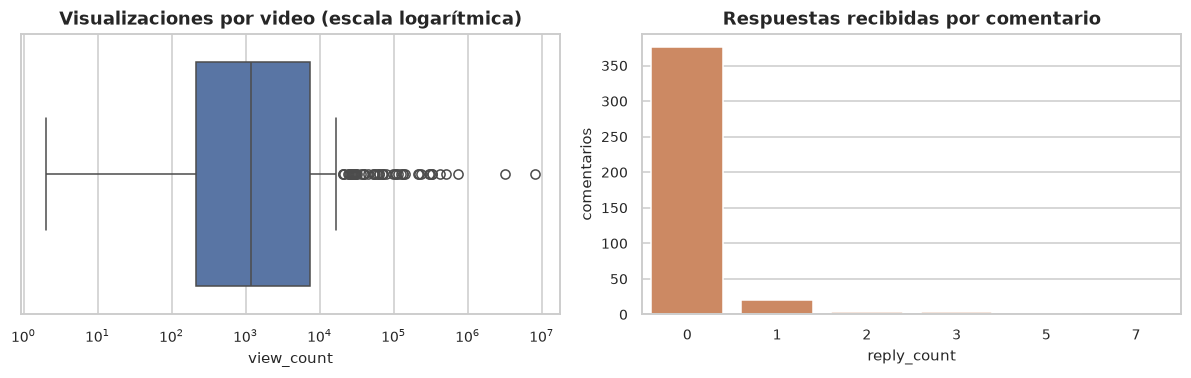

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

sns.boxplot(x=videos["view_count"], ax=axes[0], color="#4C72B0")
axes[0].set_xscale("log")
axes[0].set_title("Visualizaciones por video (escala logarítmica)")
axes[0].set_xlabel("view_count")

sns.countplot(x=comentarios["reply_count"], ax=axes[1], color="#DD8452")
axes[1].set_title("Respuestas recibidas por comentario")
axes[1].set_xlabel("reply_count")
axes[1].set_ylabel("comentarios")

plt.tight_layout()
plt.show()

In [17]:
# Consistencia entre identificadores, nombres visibles y handles
print("CANALES (youtube_videos)")
print("  channel_id con más de un channel_name:",
      (videos.groupby("channel_id")["channel_name"].nunique() > 1).sum())
print("  channel_name usado por más de un channel_id:",
      (videos.groupby("channel_name")["channel_id"].nunique() > 1).sum())
print("  channel_handle idéntico a owner_handle:",
      f"{(videos['channel_handle'] == videos['owner_handle']).mean():.1%}")
print()
print("AUTORES (youtube_comments)")
print("  author_channel_id con más de un author_name:",
      (comentarios.groupby("author_channel_id")["author_name"].nunique() > 1).sum())
print("  author_name usado por más de un author_channel_id:",
      (comentarios.groupby("author_name")["author_channel_id"].nunique() > 1).sum())
coincide_handle = comentarios["author_name"] == comentarios["author_handle"].str.replace("/", "", regex=False)
print("  author_name coincide con author_handle sin '/':", f"{coincide_handle.mean():.1%}")
print("  ejemplos donde NO coincide:")
print(comentarios.loc[~coincide_handle, ["author_name", "author_handle"]].head(5).to_string(index=False))

CANALES (youtube_videos)
  channel_id con más de un channel_name: 0
  channel_name usado por más de un channel_id: 0
  channel_handle idéntico a owner_handle: 100.0%

AUTORES (youtube_comments)
  author_channel_id con más de un author_name: 0
  author_name usado por más de un author_channel_id: 0
  author_name coincide con author_handle sin '/': 96.6%
  ejemplos donde NO coincide:
               author_name                    author_handle
@ErvinLeonardoCarreraLatín /@ErvinLeonardoCarreraLat%C3%ADn
       @AlejandroPérez-b6r        /@AlejandroP%C3%A9rez-b6r
            @ErmePérez-q4s             /@ErmeP%C3%A9rez-q4s
            @ErmePérez-q4s             /@ErmeP%C3%A9rez-q4s
            @ErmePérez-q4s             /@ErmeP%C3%A9rez-q4s


**Resumen del Diagnóstico de Calidad**

| Dimensión | Hallazgo |
| --- | --- |
| Dimensiones | 293 × 20 (videos) y 406 × 17 (comentarios) |
| Tipos | Todo llega como texto salvo `view_count`, `reply_count` (enteros), `is_pinned` (lógica) y `viewer_rating` (numérica vacía) |
| Faltantes | Videos: `description` 8.9%, `description_snippet` 8.5%, `published_time` y `view_count_text` 4.4%. Comentarios: solo `viewer_rating`, con 100% |
| Duplicados | Ninguno, ni por fila completa ni por llave primaria, en ambos archivos |
| Constantes | `is_pinned` (siempre `False`) y `viewer_rating` (siempre nula) en comentarios |
| Atípicos | `view_count` tiene mediana 1,175 frente a una media de 60,430 y un máximo de 8,190,449; el 16.7% supera el límite superior del rango intercuartílico |
| Consistencia | Perfecta entre ID y nombre: ningún `channel_id` tiene dos nombres, ningún `author_channel_id` tiene dos nombres, y `channel_handle` coincide con `owner_handle` en el 100% |

Sobre los **atípicos**: la enorme distancia entre mediana y media indica una distribución de cola pesada. Esos valores extremos **no son errores** y no deben eliminarse; simplemente obligan a describir la variable con mediana y cuantiles en lugar de promedios, y a graficarla en escala logarítmica.

La única inconsistencia aparece en los handles de autor, el 3.4% no coincide con `author_name` porque el handle conserva la codificación porcentual de las URL (ej. `%C3%A9` en lugar de `é`).

### 2.2 Variables que no pueden utilizarse o que requieren precauciones

Se recopila la evidencia que respalda las decisiones de tratamiento de cada variable delicada.

In [18]:
print("1. viewer_rating: valores no nulos =", comentarios["viewer_rating"].notna().sum(), "de", len(comentarios))
print("2. is_pinned: valores distintos =", comentarios["is_pinned"].unique())
print("3. upload_date idéntica a publish_date:", f"{(videos['upload_date'] == videos['publish_date']).mean():.1%}")
print("4. owner_handle idéntico a channel_handle:", f"{(videos['owner_handle'] == videos['channel_handle']).mean():.1%}")
print()
print("5. published_time / published_text son tiempos RELATIVOS al momento de recolección:")
print("   videos      ->", videos["published_time"].dropna().unique()[:5])
print("   comentarios ->", comentarios["published_text"].unique()[:5])
print()
print("6. reply_count: total de respuestas declaradas =", int(comentarios["reply_count"].sum()),
      "| comentarios con al menos una respuesta =", int((comentarios["reply_count"] > 0).sum()))
print("   El conjunto NO contiene el texto ni el autor de esas respuestas:")
print("   ¿existe alguna columna de comentario padre?",
      [c for c in comentarios.columns if "parent" in c.lower() or "reply_to" in c.lower()] or "no existe")

1. viewer_rating: valores no nulos = 0 de 406
2. is_pinned: valores distintos = [False]
3. upload_date idéntica a publish_date: 100.0%
4. owner_handle idéntico a channel_handle: 100.0%

5. published_time / published_text son tiempos RELATIVOS al momento de recolección:
   videos      -> ['hace 2 días' 'hace 3 meses' 'hace 1 día' 'hace 5 meses' 'hace 2 semanas']
   comentarios -> ['hace 6 meses' 'hace 2 semanas' 'hace 1 año' 'hace 1 día' 'hace 20 horas']

6. reply_count: total de respuestas declaradas = 51 | comentarios con al menos una respuesta = 30
   El conjunto NO contiene el texto ni el autor de esas respuestas:
   ¿existe alguna columna de comentario padre? no existe


**Variables que No Pueden Utilizarse o que Requieren Precaución**

| Variable | Problema Observado | Decisión |
| --- | --- | --- |
| `viewer_rating` | Nula en los 406 registros | **Se descarta.** No aporta ninguna información |
| `is_pinned` | Un único valor (`False`) en los 406 registros | **Se descarta.** Sin variabilidad, no puede discriminar nada |
| `upload_date` | Idéntica a `publish_date` en el 100% de los videos | **Se descarta** por redundante |
| `owner_handle` | Idéntico a `channel_handle` en el 100% de los videos | **Se descarta** por redundante |
| `published_time`, `published_text` | Tiempos relativos ("hace 2 años") que dependen del momento del scraping | **Se conservan pero no se convierten a fecha.** Solo admiten un uso ordinal grueso |
| `view_count_text` | Redundante frente a `view_count`, que ya es numérica | **Se conserva únicamente para validar el parser** de conteos |
| `reply_count` | Cuenta 51 respuestas en 30 comentarios, pero el conjunto no tiene columna de comentario padre ni el texto de las respuestas | **Se conserva como atributo del comentario, nunca como arista.** No identifica quién respondió a quién |
| `video_title`, `channel_name`, `channel_id` (en comentarios) | Se obtienen al unir por `video_id` | **Se eliminan de la tabla unida** para no duplicar columnas |
| `keywords`, `query_hits`, `dataset_sources` | Texto con estructura de lista | **Se convierten a lista real** antes de analizarse |
| `view_count`, `like_count`, `reply_count` | Conteos observados en el momento de la recolección | **Se usan, advirtiendo** que son un dato variable y no un valor definitivo |

El punto más delicado es `reply_count`. Es tentador leerlo como "este comentario generó conversación" y convertirlo en conexiones entre usuarios, pero los datos no dicen **quién** respondió. Usarlo como arista inventaría relaciones que no fueron observadas.

### 2.3 Normalización de identificadores y nombres

La normalización unifica la representación de las cadenas (espacios invisibles, formas Unicode equivalentes, mayúsculas en los handles) **sin sustituir ningún identificador por un nombre visible**. Los ID siguen siendo `video_id`, `channel_id`, `comment_id` y `author_channel_id`.

In [19]:
def normalizar_cadena(s):
    """Normaliza Unicode a NFKC, quita espacios extremos y colapsa espacios internos."""
    if pd.isna(s):
        return s
    s = unicodedata.normalize("NFKC", str(s))
    s = s.replace("​", "").replace("\xa0", " ")
    return re.sub(r"\s+", " ", s).strip()


def normalizar_handle(s):
    """Lleva un handle a la forma canónica '@nombre' en minúsculas.

    Se decodifica la codificación porcentual de las URL (%C3%A9 -> é), que es la causa
    de que algunos handles no coincidan con el nombre visible del autor.
    """
    if pd.isna(s):
        return s
    s = normalizar_cadena(unquote(str(s))).lstrip("/").lower()
    return s if s.startswith("@") else "@" + s


videos_limpio = videos.copy()
comentarios_limpio = comentarios.copy()

for col in ["video_id", "channel_id", "channel_name", "title", "category", "source_query", "source_group"]:
    videos_limpio[col] = videos_limpio[col].map(normalizar_cadena)
for col in ["channel_handle", "owner_handle"]:
    videos_limpio[col] = videos_limpio[col].map(normalizar_handle)

for col in ["video_id", "comment_id", "channel_id", "author_channel_id", "author_name",
            "channel_name", "video_title", "source_query", "source_group"]:
    comentarios_limpio[col] = comentarios_limpio[col].map(normalizar_cadena)
comentarios_limpio["author_handle"] = comentarios_limpio["author_handle"].map(normalizar_handle)

muestra = [1, 6, 21]
print("Ejemplo de handles normalizados (canales):")
print(pd.DataFrame({
    "original": videos.loc[muestra, "channel_handle"].tolist(),
    "normalizado": videos_limpio.loc[muestra, "channel_handle"].tolist(),
}).to_string(index=False))

antes_coincide = comentarios["author_name"].str.lower() == comentarios["author_handle"].str.replace("/", "", regex=False).str.lower()
despues_coincide = comentarios_limpio["author_name"].str.lower() == comentarios_limpio["author_handle"]
print()
print("Coincidencia entre author_name y author_handle")
print(f"  antes de normalizar:   {antes_coincide.mean():.1%}")
print(f"  después de normalizar: {despues_coincide.mean():.1%}")

Ejemplo de handles normalizados (canales):
              original           normalizado
          /@iDocumenta           @idocumenta
      /@PNCdeGuatemala       @pncdeguatemala
/@GuatevisionNoticiero @guatevisionnoticiero

Coincidencia entre author_name y author_handle
  antes de normalizar:   96.6%
  después de normalizar: 100.0%


In [20]:
# Verificación de que la normalización no fusionó ni partió identificadores
print("Identificadores únicos antes y después de normalizar")
for nombre, antes, despues in [
    ("video_id (videos)", videos["video_id"].nunique(), videos_limpio["video_id"].nunique()),
    ("channel_id", videos["channel_id"].nunique(), videos_limpio["channel_id"].nunique()),
    ("comment_id", comentarios["comment_id"].nunique(), comentarios_limpio["comment_id"].nunique()),
    ("author_channel_id", comentarios["author_channel_id"].nunique(), comentarios_limpio["author_channel_id"].nunique()),
]:
    print(f"  {nombre:22} {antes:4} -> {despues:4}  {'OK' if antes == despues else 'CAMBIÓ'}")

Identificadores únicos antes y después de normalizar
  video_id (videos)       293 ->  293  OK
  channel_id               97 ->   97  OK
  comment_id              406 ->  406  OK
  author_channel_id       332 ->  332  OK


In [21]:
# Tablas de mapeo ID -> nombre visible canónico (la etiqueta más frecuente por ID).
# Se usan SOLO para rotular gráficos; los nodos y las llaves siguen siendo los ID.
etiqueta_canal = (
    videos_limpio.groupby("channel_id")["channel_name"]
    .agg(lambda s: s.mode().iat[0])
    .rename("nombre_canal")
)
etiqueta_autor = (
    comentarios_limpio.groupby("author_channel_id")["author_name"]
    .agg(lambda s: s.mode().iat[0])
    .rename("nombre_autor")
)

print("Mapeos construidos ->", len(etiqueta_canal), "canales y", len(etiqueta_autor), "autores")
etiqueta_canal.head(3).to_frame()

Mapeos construidos -> 97 canales y 332 autores


,nombre_canal
channel_id,
UC-DpoeBbCMOMOH1-j71KPqA,México Poder
UC-GLagjBhWAZ3IOWFgzqIAw,Canal Antigua
UC-YGRGi0FeIA5441bGlHOPw,audioschileros


**¿Qué hace y qué no hace la normalización?**

Se unificó la forma de las cadenas (normalización Unicode NFKC, eliminación de espacios invisibles, handles en minúsculas con `@` inicial y decodificación de la codificación porcentual). La coincidencia entre `author_name` y
`author_handle` pasó de **96.6% a 100%**, lo que confirma que las discrepancias eran solo de codificación y no autores distintos.

Lo que **no** se hizo: el número de identificadores únicos permaneció idéntico en los cuatro casos, es decir, la normalización no fusionó ni partió ninguna entidad. Y los nombres visibles no sustituyen a los ID en ningún momento; las tablas `etiqueta_canal` y `etiqueta_autor` existen únicamente para rotular gráficos.

### 2.4 Conversión a formato numérico de los conteos almacenados como texto

In [22]:
ABREVIATURAS = {"k": 1_000, "m": 1_000_000, "mil": 1_000, "millones": 1_000_000, "b": 1_000_000_000}


def a_entero(valor):
    """Convierte un conteo escrito como texto en un entero.

    Reglas aplicadas, en orden:
      1. Los nulos y las cadenas vacías o de solo espacios se interpretan como 0
         (YouTube omite el conteo cuando no hay ninguno).
      2. Se eliminan palabras acompañantes ('vistas', 'visualizaciones') y espacios invisibles.
      3. Se detecta la abreviatura final (K, M, mil, millones) y se guarda su multiplicador.
      4. Se eliminan los separadores de miles: la coma siempre, y el punto solo cuando
         separa grupos de tres dígitos (1.406) y no cuando es decimal de una abreviatura (1.2 K).
      5. Si tras la limpieza no queda un número válido, se devuelve NaN y se marca como no parseable.
    """
    if pd.isna(valor):
        return 0
    s = unicodedata.normalize("NFKC", str(valor)).replace("\xa0", " ").strip().lower()
    if s == "":
        return 0
    s = re.sub(r"\b(vistas?|visualizaciones|reproducciones|me gusta|likes?)\b", "", s).strip()

    multiplicador = 1
    m = re.search(r"([\d.,]+)\s*(k|m|mil|millones|b)\b", s)
    if m:
        s, multiplicador = m.group(1), ABREVIATURAS[m.group(2)]

    s = s.replace(",", "")
    s = re.sub(r"\.(?=\d{3}\b)", "", s)  # punto como separador de miles
    try:
        return int(round(float(s) * multiplicador))
    except ValueError:
        return np.nan


pruebas = [" ", "", None, "1", "2,390 vistas", "1.406", "1.2 K", "2,3 mil", "1.5 M", "sin dato"]
pd.DataFrame({"entrada": [repr(p) for p in pruebas], "salida": [a_entero(p) for p in pruebas]})

,entrada,salida
0,' ',0.0
1,'',0.0
2,None,0.0
3,'1',1.0
4,"'2,390 vistas'",2390.0
5,'1.406',1406.0
6,'1.2 K',1200.0
7,"'2,3 mil'",23000.0
8,'1.5 M',1500000.0
9,'sin dato',NaN


In [23]:
comentarios_limpio["like_count"] = comentarios_limpio["like_count_text"].map(a_entero)

vacios = comentarios_limpio["like_count_text"].astype(str).str.strip().eq("").sum()
no_parseables = comentarios_limpio["like_count"].isna().sum()

print("like_count_text -> like_count")
print(f"  valores vacíos o solo espacios, interpretados como 0: {vacios} ({vacios / len(comentarios_limpio):.1%})")
print(f"  valores no parseables (NaN):                          {no_parseables}")
print(f"  formatos con abreviatura (K/M/mil) presentes:         "
      f"{comentarios_limpio['like_count_text'].astype(str).str.contains(r'[km]|mil', case=False).sum()}")
print()
pd.DataFrame([resumen_atipicos(comentarios_limpio["like_count"], "like_count (comentarios)")])

like_count_text -> like_count
  valores vacíos o solo espacios, interpretados como 0: 189 (46.6%)
  valores no parseables (NaN):                          0
  formatos con abreviatura (K/M/mil) presentes:         0



,variable,n,min,mediana,media,p90,p99,max,limite_sup_IQR,n_sobre_limite,%_sobre_limite
0,like_count (comentarios),406,0.0,1.0,5.7,7.0,111.3,405.0,5.0,48,11.8


In [24]:
# view_count_text se usa como control de calidad del parser frente a view_count, que ya es numérico
videos_limpio["view_count_parseado"] = videos_limpio["view_count_text"].map(a_entero)
tiene_texto = videos_limpio["view_count_text"].notna()

coincide = (videos_limpio.loc[tiene_texto, "view_count_parseado"]
            == videos_limpio.loc[tiene_texto, "view_count"])

print(f"Videos con view_count_text disponible: {tiene_texto.sum()} de {len(videos_limpio)}")
print(f"  el parser reproduce exactamente view_count en: {coincide.sum()} casos ({coincide.mean():.1%})")
print(f"  videos sin view_count_text (NaN): {(~tiene_texto).sum()} -> se conserva view_count original")
if (~coincide).any():
    disc = videos_limpio.loc[tiene_texto & ~coincide, ["view_count_text", "view_count_parseado", "view_count"]].copy()
    disc["dif_absoluta"] = disc["view_count_parseado"] - disc["view_count"]
    disc["dif_relativa_%"] = (disc["dif_absoluta"] / disc["view_count"] * 100).round(2)
    print(f"\nDiscrepancias: {len(disc)} videos")
    print("  diferencia relativa -> mediana:", f"{disc['dif_relativa_%'].abs().median():.2f}%",
          "| máxima:", f"{disc['dif_relativa_%'].abs().max():.2f}%")
    print(disc.head().to_string())

Videos con view_count_text disponible: 280 de 293
  el parser reproduce exactamente view_count en: 227 casos (81.1%)
  videos sin view_count_text (NaN): 13 -> se conserva view_count original

Discrepancias: 53 videos
  diferencia relativa -> mediana: 0.05% | máxima: 40.00%
   view_count_text  view_count_parseado  view_count  dif_absoluta  dif_relativa_%
0     2,390 vistas                 2390        2357            33            1.40
5     6,098 vistas                 6098        6099            -1           -0.02
6    15,436 vistas                15436       15455           -19           -0.12
16    5,180 vistas                 5180        5181            -1           -0.02
25    4,485 vistas                 4485        4484             1            0.02


**Tratamiento de los conteos almacenados como texto**

- **Separadores.** `view_count_text` usa la coma como separador de miles (`2,390 vistas`). El punto se elimina solo cuando separa grupos de tres dígitos, para no destruir los decimales de  una abreviatura como `1.2 K`.
- **Abreviaturas.** El parser reconoce `K`, `M`, `mil`, `millones` y `B`. En este conjunto **ninguno de los 406 valores de `like_count_text` usa abreviaturas**, pero la regla queda implementada porque YouTube las emplea con conteos altos.
- **Valores no válidos.** Los 189 valores vacíos o de solo espacios de `like_count_text` (46.6%) se interpretan como **0**, no como faltantes (YouTube omite el contador cuando un comentario no tiene ningún "me gusta"). **Ningún** valor resultó no parseable.
- **Validación del parser.** Al aplicarlo a `view_count_text` reproduce exactamente `view_count` en 227 de 280 videos (81.1%). Las 53 discrepancias tienen una diferencia relativa **mediana de 0.05%**, es decir, unas pocas visualizaciones. Eso indica que el parser funciona y que ambos campos se capturaron en instantes ligeramente distintos, no que haya un error de conversión. Se conserva `view_count` como variable oficial.

### 2.5 Creación de `texto_original` y `texto_limpio`

In [25]:
comentarios_limpio["texto_original"] = comentarios_limpio["text"].astype(str)

crudo = comentarios_limpio["texto_original"]
longitud_original = crudo.str.len()
n_url = crudo.str.contains(r"https?://|www\.", case=False).sum()
n_mencion = crudo.str.contains(r"(?<!\w)@\w+").sum()
n_hashtag = crudo.str.contains(r"(?<!\w)#\w+").sum()
n_emoji = sum(emoji.emoji_count(t) > 0 for t in crudo)

print("Características del texto crudo de los comentarios")
print(f"  registros:                     {len(comentarios_limpio)}")
print(f"  longitud en caracteres  -> mín: {longitud_original.min()} | "
      f"mediana: {longitud_original.median():.0f} | máx: {longitud_original.max()}")
print(f"  contienen URL:                 {n_url}")
print(f"  contienen mención @:           {n_mencion}")
print(f"  contienen hashtag #:           {n_hashtag}")
print(f"  contienen al menos un emoji:   {n_emoji}")
print(f"  textos exactamente duplicados: {crudo.duplicated().sum()}")

Características del texto crudo de los comentarios
  registros:                     406
  longitud en caracteres  -> mín: 1 | mediana: 96 | máx: 1525
  contienen URL:                 1
  contienen mención @:           5
  contienen hashtag #:           1
  contienen al menos un emoji:   61
  textos exactamente duplicados: 2


**¿Por qué se conservan dos versiones del texto?**

`texto_original` es una copia exacta del comentario. Se conserva por dos razones: permite auditar cualquier resultado volviendo al texto tal como fue publicado, y es la entrada correcta para el **análisis de sentimiento** del Ejercicio 9, que necesita las mayúsculas, los signos de admiración, la puntuación y los emojis que la limpieza elimina.

`texto_limpio` se construye para lo contrario: contar palabras, bigramas y temas, donde esas mismas marcas solo introducen ruido.

Los textos son cortos (mediana de 96 caracteres) y contienen muy pocos elementos de red social. Una sola URL, cinco menciones y un solo hashtag en los 406 comentarios. Los emojis sí son frecuentes y aparecen en 62 comentarios, contando tanto los caracteres Unicode como los emojis propios de YouTube, que llegan escritos como texto (`:hand-purple-blue-peace:`) y que la librería `emoji` no reconoce por sí sola.

### 2.6 Construcción de `texto_limpio`

La limpieza se aplica por pasos. Cada paso se ejecuta por separado para poder medir cuántos textos modifica y así justificar su inclusión.

In [ ]:
# Paso A. Extracción de los elementos que se retiran del texto pero se conservan como columnas
RE_URL = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
RE_MENCION = re.compile(r"(?<!\w)@([A-Za-z0-9_.\-]+)")
RE_HASHTAG = re.compile(r"(?<!\w)#(\w+)", re.UNICODE)
# YouTube inserta algunos de sus emojis propios como texto, con la forma :nombre-con-guiones
# La librería `emoji` no los detecta porque no son caracteres Unicode.
RE_EMOJI_YT = re.compile(r":[a-záéíóúñ]+(?:-[a-záéíóúñ]+)+:", re.IGNORECASE)


def extraer_elementos(texto):
    return pd.Series({
        "urls": RE_URL.findall(texto),
        "menciones": [m.lower() for m in RE_MENCION.findall(texto)],
        "hashtags": [h.lower() for h in RE_HASHTAG.findall(texto)],
        "emojis": emoji.distinct_emoji_list(texto) + RE_EMOJI_YT.findall(texto),
    })


extraidos = comentarios_limpio["texto_original"].apply(extraer_elementos)
comentarios_limpio = pd.concat([comentarios_limpio, extraidos], axis=1)

print("Elementos extraídos del texto de los comentarios")
for col in ["urls", "menciones", "hashtags", "emojis"]:
    n_textos = comentarios_limpio[col].map(len).gt(0).sum()
    n_total = comentarios_limpio[col].map(len).sum()
    print(f"  {col:10} -> {n_textos:3} comentarios los contienen | {n_total:3} ocurrencias en total")

Elementos extraídos del texto de los comentarios
  urls       ->   1 comentarios los contienen |   1 ocurrencias en total
  menciones  ->   5 comentarios los contienen |   5 ocurrencias en total
  hashtags   ->   1 comentarios los contienen |   1 ocurrencias en total
  emojis     ->  62 comentarios los contienen | 100 ocurrencias en total


In [27]:
# Definición de cada paso de limpieza como una función independiente
def p1_normalizar(t):
    return re.sub(r"\s+", " ", unicodedata.normalize("NFKC", t).replace("\xa0", " ")).strip()

def p2_quitar_urls(t):
    return RE_URL.sub(" ", t)

def p3_quitar_menciones(t):
    return RE_MENCION.sub(" ", t)

def p4_separar_hashtags(t):
    # Se conserva la palabra del hashtag porque aporta tema; solo se elimina el símbolo '#'
    return RE_HASHTAG.sub(r" \1 ", t)

def p5_quitar_emojis(t):
    # Se eliminan tanto los emojis Unicode como los propios de YouTube escritos como texto
    return emoji.replace_emoji(RE_EMOJI_YT.sub(" ", t), replace=" ")

def p6_minusculas(t):
    return t.lower()

def p7_quitar_numeros(t):
    return re.sub(r"\d+", " ", t)

def p8_quitar_puntuacion(t):
    # Se conservan letras (incluidas tildes y ñ) y espacios; el resto se sustituye por espacio
    return re.sub(r"[^a-záéíóúüñ\s]", " ", t)

PASOS = [
    ("1. normalización Unicode y espacios", p1_normalizar),
    ("2. eliminación de URL", p2_quitar_urls),
    ("3. eliminación de menciones @", p3_quitar_menciones),
    ("4. separación de hashtags (se conserva la palabra)", p4_separar_hashtags),
    ("5. eliminación de emojis (Unicode y de YouTube)", p5_quitar_emojis),
    ("6. conversión a minúsculas", p6_minusculas),
    ("7. eliminación de números", p7_quitar_numeros),
    ("8. eliminación de puntuación y símbolos", p8_quitar_puntuacion),
]

efecto = []
texto = comentarios_limpio["texto_original"].copy()
for nombre, funcion in PASOS:
    nuevo = texto.map(funcion).str.replace(r"\s+", " ", regex=True).str.strip()
    efecto.append({
        "paso": nombre,
        "textos_modificados": int((nuevo != texto).sum()),
        "long_media_despues": round(nuevo.str.len().mean(), 1),
        "vacios_despues": int((nuevo == "").sum()),
    })
    texto = nuevo

pd.DataFrame(efecto)

,paso,textos_modificados,long_media_despues,vacios_despues
0,1. normalización Unicode y espacios,110,138.6,0
1,2. eliminación de URL,1,138.4,0
2,3. eliminación de menciones @,5,138.2,0
3,4. separación de hashtags (se conserva la pala...,1,138.2,0
4,5. eliminación de emojis (Unicode y de YouTube),62,137.3,4
5,6. conversión a minúsculas,380,137.3,4
6,7. eliminación de números,42,136.8,4
7,8. eliminación de puntuación y símbolos,265,134.1,5


**Decisiones de Limpieza y su Efecto**

| Paso | Decisión | Justificación | Textos Modificados |
| --- | --- | --- | --- |
| 1 | Normalización Unicode NFKC y colapso de espacios | Unifica caracteres visualmente idénticos y elimina espacios invisibles | 110 |
| 2 | Eliminación de URL | Una dirección web no es vocabulario; se guarda aparte en la columna `urls` | 1 |
| 3 | Eliminación de menciones `@` | Identifican cuentas, no temas; se guardan en `menciones` | 5 |
| 4 | Separación de hashtags | Se elimina el `#` pero **se conserva la palabra**, porque sí aporta tema; la etiqueta completa se guarda en `hashtags` | 1 |
| 5 | Eliminación de emojis | Se extraen a la columna `emojis` porque son señal de sentimiento, pero distorsionan el conteo de palabras. Incluye los emojis propios de YouTube, que llegan como texto (`:face-blue-smiling:`) y que la librería `emoji` no detecta | 62 |
| 6 | Conversión a minúsculas | Evita que *Guatemala* y *guatemala* cuenten como dos palabras | 380 |
| 7 | Eliminación de números | Las cifras sueltas no aportan tema en este corpus | 42 |
| 8 | Eliminación de puntuación y símbolos | Se conservan tildes y `ñ`, necesarias para el español | 266 |
| 9 | Eliminación de stopwords | 533 palabras vacías (521 de spaCy más 20 añadidas: `q`, `xq`, `jaja`, etc., observadas en el corpus) | — |
| 10 | Lematización | Reduce *comentaron*, *comentando* y *comentar* a `comentar` | — |
| 11 | Separación de lemas compuestos | spaCy devuelve dos palabras al lematizar un pronombre pegado al verbo (*darle* → *dar él*); se separan y cada parte se evalúa aparte | — |

Sobre los últimos 2 pasos:

- **Lematización y no derivación (*stemming*).** La derivación corta las palabras de forma mecánica y produce raíces que no son palabras reales (*comentari*), difíciles de leer en un gráfico. La lematización usa el modelo gramatical de spaCy para español y devuelve el lema del diccionario, lo que hace interpretables los conteos de frecuencia. El costo es que el modelo se equivoca a veces con formas coloquiales.
- **Longitud mínima de 3 caracteres**, para descartar restos de la limpieza.

In [28]:
# Paso B. Tokenización, eliminación de stopwords en español y lematización con spaCy.
# Se desactivan los componentes que no se necesitan (analizador sintáctico y NER) por rapidez.
nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])

STOPWORDS = set(nlp.Defaults.stop_words)
# Adiciones observadas en el corpus: muletillas, abreviaturas de chat y risas
EXTRA_STOPWORDS = {"q", "xq", "pq", "d", "x", "k", "jaja", "jajaja", "jajajaja", "jeje",
                   "ja", "je", "si", "solo", "asi", "aqui", "ahi", "ser", "haber", "tener"}
STOPWORDS |= EXTRA_STOPWORDS

LONGITUD_MINIMA = 3


def lematizar(doc):
    """Devuelve los lemas útiles de un documento ya limpiado.

    spaCy lematiza los pronombres pegados al verbo como dos palabras ('darle' -> 'dar él'),
    así que el lema se divide en sus partes y cada una se evalúa por separado.
    """
    lemas = []
    for t in doc:
        if not t.is_alpha or t.lower_ in STOPWORDS:
            continue
        for lema in t.lemma_.lower().split():
            if len(lema) >= LONGITUD_MINIMA and lema not in STOPWORDS:
                lemas.append(lema)
    return lemas


tokens = [lematizar(doc) for doc in nlp.pipe(texto.tolist(), batch_size=64)]
comentarios_limpio["tokens"] = tokens
comentarios_limpio["texto_limpio"] = [" ".join(t) for t in tokens]

print("Stopwords en español utilizadas:", len(STOPWORDS),
      f"({len(nlp.Defaults.stop_words)} de spaCy + {len(EXTRA_STOPWORDS)} añadidas)")
print("Longitud mínima de token conservada:", LONGITUD_MINIMA, "caracteres")
print()
ejemplo = comentarios_limpio.loc[[3, 10, 25], ["texto_original", "texto_limpio"]]
for _, fila in ejemplo.iterrows():
    print("ORIGINAL:", fila["texto_original"][:120])
    print("LIMPIO  :", fila["texto_limpio"][:120])
    print()

Stopwords en español utilizadas: 533 (521 de spaCy + 20 añadidas)
Longitud mínima de token conservada: 3 caracteres

ORIGINAL: Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo en la sombra.
LIMPIO  : mafioso mazariego cárcel tiempo sombra

ORIGINAL: Otro pequeño truco es que tenés un plan mensual de Gb y redes ilimitadas y luego te mandan mensaje que consumiste el 95%
LIMPIO  : pequeño truco tenés plan mensual red ilimitado mandan mensaje consumistir plan venir caos verifica consumo dato utilizar

ORIGINAL: Pero hay que ver el lado bueno si los deportan por la Frontera los carteles los secuestran para sacar dinero a los famil
LIMPIO  : deportar frontera cartel secuestrar sacar dinero familiar



In [29]:
# La misma limpieza se aplica al texto de los videos (título + descripción),
# porque el análisis exploratorio necesita sus palabras, bigramas y hashtags.
def limpiar_texto(t):
    for _, funcion in PASOS:
        t = funcion(t)
    return re.sub(r"\s+", " ", t).strip()


videos_limpio["texto_original"] = (
    videos_limpio["title"].fillna("") + " " + videos_limpio["description"].fillna("")
).str.strip()

extraidos_v = videos_limpio["texto_original"].apply(extraer_elementos)
videos_limpio = pd.concat([videos_limpio, extraidos_v], axis=1)

texto_v = videos_limpio["texto_original"].map(limpiar_texto)
tokens_v = [lematizar(doc) for doc in nlp.pipe(texto_v.tolist(), batch_size=64)]
videos_limpio["tokens"] = tokens_v
videos_limpio["texto_limpio"] = [" ".join(t) for t in tokens_v]

# keywords y query_hits vienen como texto con estructura de lista y se convierten a lista real
videos_limpio["keywords"] = videos_limpio["keywords"].fillna("[]").map(ast.literal_eval)
videos_limpio["query_hits"] = videos_limpio["query_hits"].fillna("[]").map(ast.literal_eval)

print("Videos con hashtags en título o descripción:", videos_limpio["hashtags"].map(len).gt(0).sum())
print("Hashtags totales en videos:", videos_limpio["hashtags"].map(len).sum())
print("Videos con lista de keywords no vacía:", videos_limpio["keywords"].map(len).gt(0).sum())
print("Tokens promedio por video:", round(np.mean([len(t) for t in tokens_v]), 1))

Videos con hashtags en título o descripción: 122
Hashtags totales en videos: 586
Videos con lista de keywords no vacía: 131
Tokens promedio por video: 34.1


**Aplicación al texto de los videos**

La misma función de limpieza se aplicó al título y la descripción de cada video, porque el análisis exploratorio necesita sus palabras y sus hashtags. En estos hay **586 hashtags en 122 videos**, frente a uno solo en los 406 comentarios. Los hashtags en este conjunto son un recurso de quien publica, no de quien comenta.

### 2.7 Efecto cuantificado de la limpieza

In [30]:
antes = comentarios_limpio["texto_original"]
despues = comentarios_limpio["texto_limpio"]

comparacion = pd.DataFrame({
    "antes (texto_original)": {
        "registros": len(antes),
        "caracteres (media)": round(antes.str.len().mean(), 1),
        "caracteres (mediana)": antes.str.len().median(),
        "tokens (media)": round(antes.str.split().str.len().mean(), 1),
        "textos vacíos": int((antes.str.strip() == "").sum()),
        "textos duplicados exactos": int(antes.duplicated().sum()),
        "vocabulario (palabras distintas)": len(set(" ".join(antes.str.lower()).split())),
    },
    "después (texto_limpio)": {
        "registros": len(despues),
        "caracteres (media)": round(despues.str.len().mean(), 1),
        "caracteres (mediana)": despues.str.len().median(),
        "tokens (media)": round(despues.str.split().str.len().mean(), 1),
        "textos vacíos": int((despues.str.strip() == "").sum()),
        "textos duplicados exactos": int(despues.duplicated().sum()),
        "vocabulario (palabras distintas)": len(set(" ".join(despues).split())),
    },
})
comparacion

,antes (texto_original),después (texto_limpio)
registros,406.0,406.0
caracteres (media),139.2,73.3
caracteres (mediana),96.5,52.0
tokens (media),24.1,9.5
textos vacíos,0.0,10.0
textos duplicados exactos,2.0,14.0
vocabulario (palabras distintas),3171.0,1873.0


In [ ]:
# Ningún registro se elimina, los textos que quedan vacíos se marcan con una bandera,
# para no perder al autor ni su participación al construir la red del Ejercicio 4.
comentarios_limpio["texto_limpio_vacio"] = comentarios_limpio["texto_limpio"].str.strip() == ""

print("Registros eliminados por la limpieza:", 0)
print("Comentarios marcados con texto_limpio_vacio:",
      int(comentarios_limpio["texto_limpio_vacio"].sum()),
      f"({comentarios_limpio['texto_limpio_vacio'].mean():.1%})")
print("Autores que se habrían perdido si se eliminaran esos registros:",
      comentarios_limpio.loc[comentarios_limpio["texto_limpio_vacio"], "author_channel_id"].nunique())
print()
print("Ejemplos de comentarios que quedan vacíos tras limpiar:")
print(comentarios_limpio.loc[comentarios_limpio["texto_limpio_vacio"], "texto_original"].head(6).to_string())

Registros eliminados por la limpieza: 0
Comentarios marcados con texto_limpio_vacio: 10 (2.5%)
Autores que se habrían perdido si se eliminaran esos registros: 9

Ejemplos de comentarios que quedan vacíos tras limpiar:
38                            😮
49                           ❤🎉
97                         que?
112                     Cierto.
129                          😂😂
139    ​ @Murmullodelbarrio 👍🇬🇹


**Efecto de la Limpieza**

El texto se reduce aproximadamente a la mitad: de 139.2 a 73.3 caracteres de media, y de 24.1 a 9.5 palabras. El vocabulario baja de 3,171 a 1,873 palabras distintas.

Efectos secundarios:

- **Textos duplicados: de 2 a 14.** Comentarios que eran distintos en su forma original quedan idénticos al limpiarlos (por ejemplo, si solo se diferenciaban en mayúsculas o emojis). Es esperable y no se corrige, pero debe recordarse al contar textos únicos.
- **Textos vacíos: de 0 a 10 (2.5%).** Son comentarios formados únicamente por emojis, por una palabra vacía o por una mención, como se ve en los ejemplos.

**No se eliminó ningún registro.** Los 10 comentarios que quedan vacíos se marcan con la bandera `texto_limpio_vacio`. Borrarlos habría eliminado a 9 autores de la red del Ejercicio 4, y esos autores sí participaron (comentar con un emoji es participación observada). La bandera permite excluirlos del análisis de texto sin perderlos en el análisis de red.

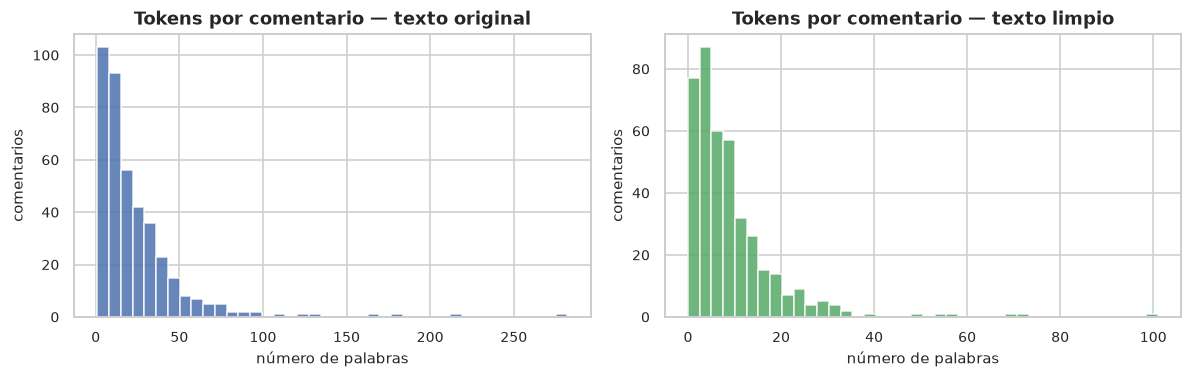

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(antes.str.split().str.len(), bins=40, color="#4C72B0", alpha=0.85)
axes[0].set_title("Tokens por comentario — texto original")
axes[0].set_xlabel("número de palabras")
axes[0].set_ylabel("comentarios")

axes[1].hist(despues.str.split().str.len(), bins=40, color="#55A868", alpha=0.85)
axes[1].set_title("Tokens por comentario — texto limpio")
axes[1].set_xlabel("número de palabras")
axes[1].set_ylabel("comentarios")

plt.tight_layout()
plt.show()

### Guardado de los conjuntos procesados

Se descartan las variables declaradas inutilizables y se guardan tres archivos: los videos limpios, los comentarios limpios y la unión de ambos por `video_id`.

In [33]:
comentarios_limpio = comentarios_limpio.drop(columns=["viewer_rating", "is_pinned", "text"])
videos_limpio = videos_limpio.drop(columns=["upload_date", "owner_handle", "view_count_parseado"])

# En la unión se eliminan del lado de los comentarios las columnas redundantes que
# ya aporta el catálogo de videos, y se distingue el origen de las que se conservan.
comentarios_para_union = comentarios_limpio.drop(columns=["video_title", "channel_name", "channel_id"])
comentarios_videos = comentarios_para_union.merge(
    videos_limpio, on="video_id", how="left", suffixes=("_comentario", "_video")
)

print("videos_limpio      ->", videos_limpio.shape)
print("comentarios_limpio ->", comentarios_limpio.shape)
print("comentarios_videos ->", comentarios_videos.shape)
print("\nFilas sin video correspondiente en la unión:",
      int(comentarios_videos["channel_id"].isna().sum()))

videos_limpio      -> (293, 25)
comentarios_limpio -> (406, 23)
comentarios_videos -> (406, 44)

Filas sin video correspondiente en la unión: 0


In [34]:
# Las columnas de listas se guardan como listas; parquet las admite sin problema.
for nombre, df in [("videos_limpio", videos_limpio),
                   ("comentarios_limpio", comentarios_limpio),
                   ("comentarios_videos", comentarios_videos)]:
    ruta = guardar(df, nombre)
    print(f"  guardado {nombre:20} -> {ruta.name}  ({df.shape[0]} x {df.shape[1]})")

  guardado videos_limpio        -> videos_limpio.parquet  (293 x 25)
  guardado comentarios_limpio   -> comentarios_limpio.parquet  (406 x 23)
  guardado comentarios_videos   -> comentarios_videos.parquet  (406 x 44)
